# 5: Data Visualization & Interactive Dashboard
**Pipeline Stage:** Present business insights through rich visualizations.

This notebook demonstrates:
- Static EDA plots (Matplotlib / Seaborn)
- Interactive Plotly charts
- A self-contained **Dash** web dashboard served from the notebook
- Business KPIs and insight annotations

In [1]:
%pip install pandas matplotlib seaborn plotly dash sqlite3

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement sqlite3 (from versions: none)
ERROR: No matching distribution found for sqlite3


In [2]:
%pip install nbformat

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')

BASE_DIR   = Path('..').resolve()
OUTPUT_DIR = BASE_DIR / 'outputs'
DB_PATH    = OUTPUT_DIR / 'pipeline.db'

# Load the original (pre-SMOTE) session data for realistic EDA
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql("SELECT * FROM sessions WHERE ingestion_source='csv_batch'", conn)
conn.close()
df['Revenue'] = df['Revenue'].astype(int)
print(f"Loaded {len(df):,} sessions")

Loaded 12,205 sessions


## 5.1  EDA — Static Plots

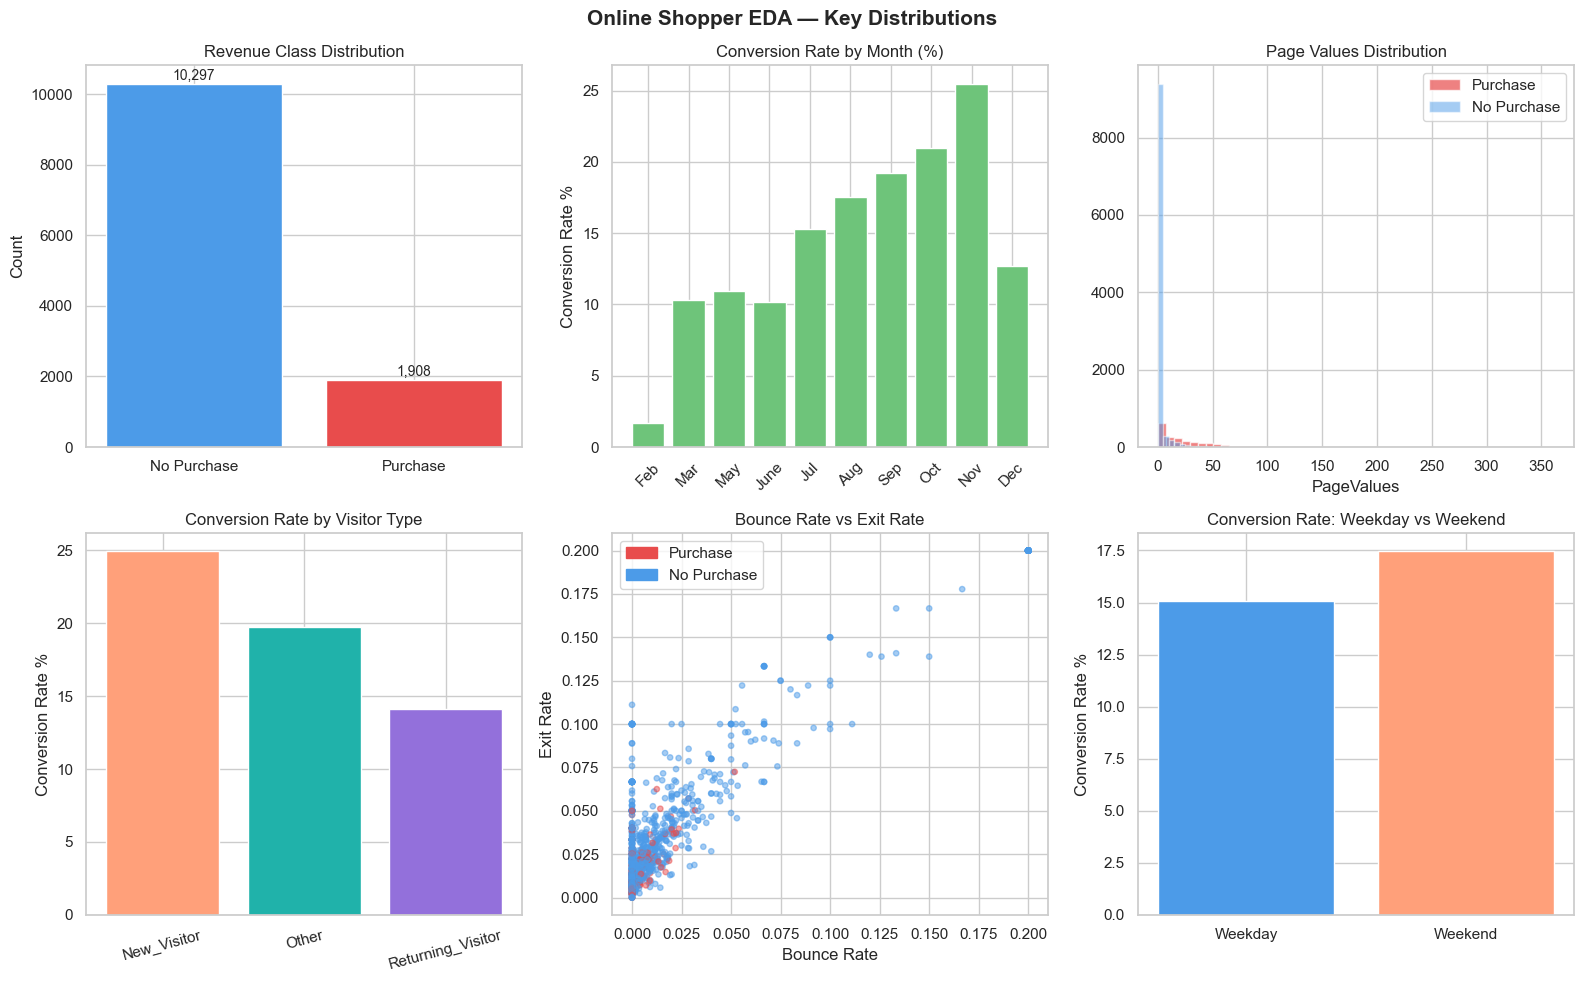

Saved: outputs/eda_overview.png


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Online Shopper EDA — Key Distributions', fontsize=15, fontweight='bold')

# 1. Class distribution
ax = axes[0,0]
counts = df['Revenue'].value_counts()
bars = ax.bar(['No Purchase','Purchase'], counts.values, color=['#4C9BE8','#E84C4C'], edgecolor='white')
ax.set_title('Revenue Class Distribution')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+100, f'{b.get_height():,}', ha='center', fontsize=10)
ax.set_ylabel('Count')

# 2. Conversion by month
ax = axes[0,1]
month_order = ['Jan','Feb','Mar','Apr','May','June','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df.groupby('Month')['Revenue'].agg(['sum','count'])
monthly['rate'] = monthly['sum']/monthly['count']*100
monthly = monthly.reindex([m for m in month_order if m in monthly.index])
ax.bar(monthly.index, monthly['rate'], color='#6EC47A', edgecolor='white')
ax.set_title('Conversion Rate by Month (%)')
ax.set_ylabel('Conversion Rate %')
ax.tick_params(axis='x', rotation=45)

# 3. PageValues distribution (log scale)
ax = axes[0,2]
ax.hist(df[df['Revenue']==1]['PageValues'], bins=50, alpha=0.7, label='Purchase', color='#E84C4C')
ax.hist(df[df['Revenue']==0]['PageValues'], bins=50, alpha=0.5, label='No Purchase', color='#4C9BE8')
ax.set_title('Page Values Distribution')
ax.set_xlabel('PageValues')
ax.legend()

# 4. Visitor type breakdown
ax = axes[1,0]
vtype_conv = df.groupby('VisitorType')['Revenue'].agg(['mean','count']).reset_index()
bars = ax.bar(vtype_conv['VisitorType'], vtype_conv['mean']*100, color=['#FFA07A','#20B2AA','#9370DB'])
ax.set_title('Conversion Rate by Visitor Type')
ax.set_ylabel('Conversion Rate %')
ax.tick_params(axis='x', rotation=15)

# 5. Bounce rate vs Exit rate (scatter)
ax = axes[1,1]
sample = df.sample(1000, random_state=42)
colors = ['#E84C4C' if r else '#4C9BE8' for r in sample['Revenue']]
ax.scatter(sample['BounceRates'], sample['ExitRates'], c=colors, alpha=0.5, s=15)
ax.set_title('Bounce Rate vs Exit Rate')
ax.set_xlabel('Bounce Rate')
ax.set_ylabel('Exit Rate')
ax.legend(handles=[mpatches.Patch(color='#E84C4C',label='Purchase'),
                   mpatches.Patch(color='#4C9BE8',label='No Purchase')])

# 6. Weekend vs Weekday conversion
ax = axes[1,2]
wknd = df.groupby('Weekend')['Revenue'].mean() * 100
ax.bar(['Weekday','Weekend'], [wknd[0], wknd[1]], color=['#4C9BE8','#FFA07A'], edgecolor='white')
ax.set_title('Conversion Rate: Weekday vs Weekend')
ax.set_ylabel('Conversion Rate %')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: outputs/eda_overview.png")

## 5.2  Correlation Heatmap

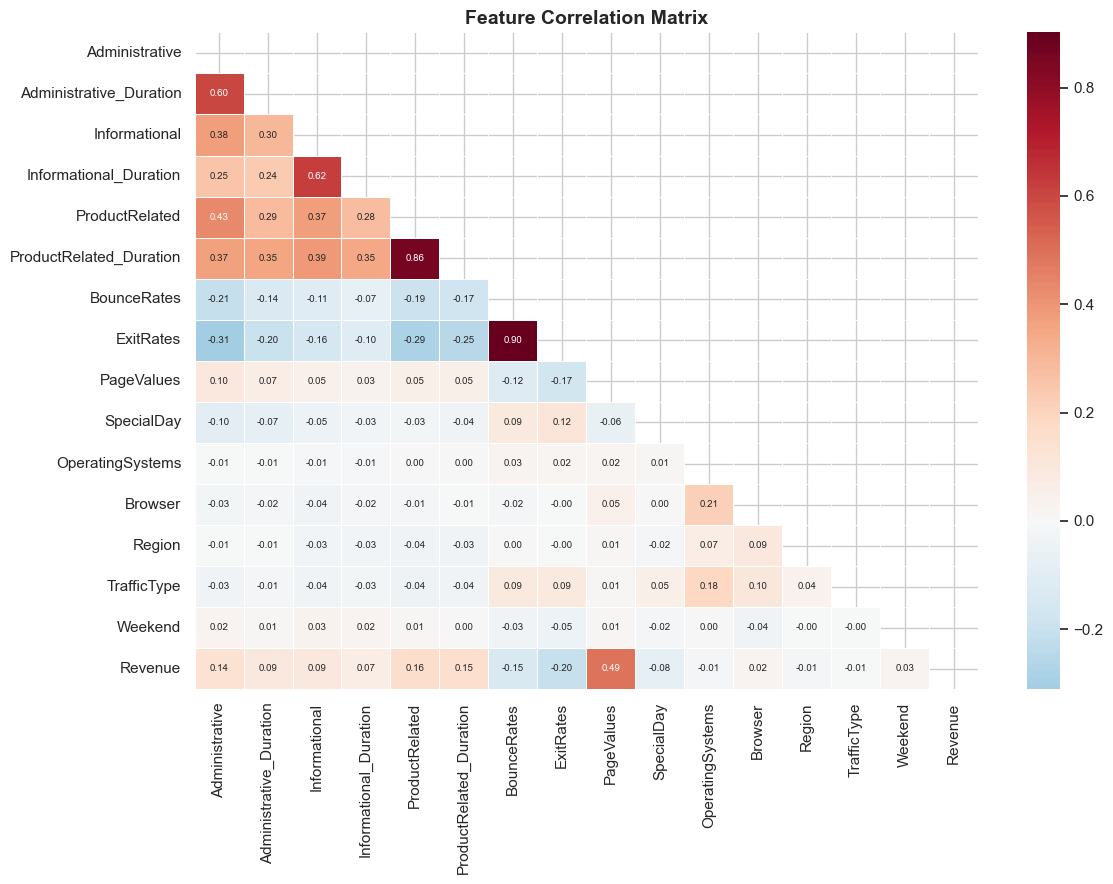

In [5]:
numeric_df = df.select_dtypes(include='number').drop(columns=['id','row_id'], errors='ignore')
corr = numeric_df.corr()

plt.figure(figsize=(12,9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, annot_kws={'size':7})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## 5.3  Interactive Plotly Charts

In [6]:
# Sunburst: Sessions breakdown by Month → VisitorType → Revenue
df_agg = df.groupby(['Month','VisitorType','Revenue']).size().reset_index(name='Count')
df_agg['Revenue_Label'] = df_agg['Revenue'].map({0:'No Purchase',1:'Purchase'})

fig = px.sunburst(
    df_agg,
    path=['Month','VisitorType','Revenue_Label'],
    values='Count',
    color='Count',
    color_continuous_scale='RdBu',
    title='Session Breakdown: Month → Visitor Type → Outcome'
)
fig.update_layout(width=700, height=600)
fig.show()

In [7]:
# Interactive scatter: PageValues vs ProductRelated_Duration coloured by Revenue
sample = df.sample(3000, random_state=42)
fig2 = px.scatter(
    sample,
    x='ProductRelated_Duration',
    y='PageValues',
    color=sample['Revenue'].map({0:'No Purchase',1:'Purchase'}),
    color_discrete_map={'No Purchase':'#4C9BE8','Purchase':'#E84C4C'},
    opacity=0.6,
    hover_data=['BounceRates','ExitRates','VisitorType','Month'],
    title='PageValues vs Product Duration (coloured by Purchase Outcome)',
    labels={'color':'Outcome'}
)
fig2.update_layout(width=800, height=500)
fig2.show()

In [8]:
# KPI summary bar chart
kpis = {
    'Overall Conversion Rate (%)': round(df['Revenue'].mean()*100,2),
    'Avg Page Value (converted)':  round(df[df['Revenue']==1]['PageValues'].mean(),2),
    'Avg Page Value (all)':        round(df['PageValues'].mean(),2),
    'Avg Bounce Rate (%)':         round(df['BounceRates'].mean()*100,2),
    'Weekend Conversion Rate (%)': round(df[df['Weekend']==1]['Revenue'].mean()*100,2),
}
fig3 = go.Figure(go.Bar(
    x=list(kpis.keys()), y=list(kpis.values()),
    marker_color=['#6EC47A','#E84C4C','#4C9BE8','#FFA07A','#9370DB'],
    text=[f"{v}" for v in kpis.values()], textposition='outside'
))
fig3.update_layout(title='Key Business KPIs', height=450, yaxis_title='Value')
fig3.show()

## 5.4  Dash Interactive Dashboard
Run the cell below to start a local dashboard on **http://127.0.0.1:8050**

In [9]:
%pip install dash
import dash
from dash import dcc, html, Input, Output
import plotly.express as px
import threading

app_dash = dash.Dash(__name__)

month_options = [{'label': m, 'value': m} for m in
                 ['Jan','Feb','Mar','Apr','May','June','Jul','Aug','Sep','Oct','Nov','Dec']
                 if m in df['Month'].unique()]

app_dash.layout = html.Div([
    html.H1('Online Shopper Intelligence Dashboard',
            style={'textAlign':'center','fontFamily':'Arial','color':'#2c3e50'}),

    html.Div([
        html.Label('Filter by Month:', style={'fontFamily':'Arial'}),
        dcc.Dropdown(
            id='month-filter',
            options=[{'label':'All','value':'All'}] + month_options,
            value='All', clearable=False, style={'width':'300px'}
        )
    ], style={'margin':'20px'}),

    html.Div(id='kpi-cards', style={'display':'flex','gap':'20px','margin':'0 20px 20px 20px'}),

    html.Div([
        dcc.Graph(id='conversion-by-visitor', style={'flex':1}),
        dcc.Graph(id='pageval-histogram',     style={'flex':1}),
    ], style={'display':'flex','gap':'10px','margin':'0 20px'}),

    dcc.Graph(id='monthly-trend', style={'margin':'10px 20px'}),
], style={'backgroundColor':'#f5f6fa'})


@app_dash.callback(
    Output('kpi-cards',              'children'),
    Output('conversion-by-visitor',  'figure'),
    Output('pageval-histogram',      'figure'),
    Output('monthly-trend',          'figure'),
    Input('month-filter',            'value')
)
def update_dashboard(month):
    filtered = df if month == 'All' else df[df['Month'] == month]

    # KPI cards
    total      = len(filtered)
    conv_rate  = filtered['Revenue'].mean() * 100
    avg_pv     = filtered[filtered['Revenue']==1]['PageValues'].mean()
    avg_bounce = filtered['BounceRates'].mean() * 100

    card_style = {'background':'white','padding':'15px 20px','borderRadius':'8px',
                  'boxShadow':'0 2px 4px rgba(0,0,0,0.1)','fontFamily':'Arial','flex':1}
    cards = [
        html.Div([html.H3(f'{total:,}', style={'margin':0,'color':'#2c3e50'}),
                  html.P('Total Sessions', style={'margin':0,'color':'#7f8c8d'})], style=card_style),
        html.Div([html.H3(f'{conv_rate:.1f}%', style={'margin':0,'color':'#27ae60'}),
                  html.P('Conversion Rate',   style={'margin':0,'color':'#7f8c8d'})], style=card_style),
        html.Div([html.H3(f'{avg_pv:.1f}' if not np.isnan(avg_pv) else 'N/A',
                          style={'margin':0,'color':'#e74c3c'}),
                  html.P('Avg Page Value (Buyers)', style={'margin':0,'color':'#7f8c8d'})], style=card_style),
        html.Div([html.H3(f'{avg_bounce:.1f}%', style={'margin':0,'color':'#e67e22'}),
                  html.P('Avg Bounce Rate',    style={'margin':0,'color':'#7f8c8d'})], style=card_style),
    ]

    # Visitor type chart
    vt = filtered.groupby('VisitorType')['Revenue'].mean().reset_index()
    vt['ConvRate'] = vt['Revenue'] * 100
    fig_vt = px.bar(vt, x='VisitorType', y='ConvRate',
                    title='Conversion by Visitor Type',
                    color='ConvRate', color_continuous_scale='Greens')
    fig_vt.update_layout(showlegend=False)

    # Page value histogram
    fig_pv = px.histogram(filtered, x='PageValues', color=filtered['Revenue'].map({0:'No Purchase',1:'Purchase'}),
                          barmode='overlay', title='Page Value Distribution',
                          color_discrete_map={'No Purchase':'#4C9BE8','Purchase':'#E84C4C'},
                          labels={'color':'Outcome'})

    # Monthly trend
    month_order = ['Jan','Feb','Mar','Apr','May','June','Jul','Aug','Sep','Oct','Nov','Dec']
    mt = df.groupby('Month').agg(sessions=('Revenue','count'), purchases=('Revenue','sum')).reset_index()
    mt['rate'] = mt['purchases'] / mt['sessions'] * 100
    mt['Month_ord'] = mt['Month'].map({m:i for i,m in enumerate(month_order)})
    mt = mt.sort_values('Month_ord')
    fig_mt = px.line(mt, x='Month', y='rate', markers=True,
                     title='Monthly Conversion Rate Trend (%)',
                     labels={'rate':'Conversion Rate (%)'})
    fig_mt.update_traces(line_color='#e74c3c', line_width=2.5)

    return cards, fig_vt, fig_pv, fig_mt


def run_dash():
    app_dash.run(host='127.0.0.1', port=8050, debug=False, use_reloader=False)

dash_thread = threading.Thread(target=run_dash, daemon=True)
dash_thread.start()

import time; time.sleep(2)
print("Dash dashboard running at: http://127.0.0.1:8050")

Note: you may need to restart the kernel to use updated packages.


Dash dashboard running at: http://127.0.0.1:8050


## 5.5  Full Architecture Summary

```
┌───────────────────────────────────────────────────────────────────┐
│           ONLINE SHOPPER INTELLIGENCE PIPELINE                    │
├───────────┬───────────────────────────────────────────────────────┤
│  INGEST   │  CSV Batch  │  Simulated API  │  Kafka Stream         │
│           │  (12,330 rows)  (pagination)    (200 events/min)      │
├───────────┼───────────────────────────────────────────────────────┤
│  STORE    │  SQLite (SQL)  │  TinyDB (NoSQL)  │  Parquet (Lake)   │
│           │  Schema + checksums + role-based access               │
├───────────┼───────────────────────────────────────────────────────┤
│  PROCESS  │  ETL Pipeline (Airflow DAG pattern):                  │
│           │  Clean → Feature Eng → Encode → Scale → SMOTE        │
├───────────┼───────────────────────────────────────────────────────┤
│  MODEL    │  Random Forest Classifier (ROC-AUC=0.92)             │
│           │  FastAPI REST:  /predict  /predict_batch  /docs       │
├───────────┼───────────────────────────────────────────────────────┤
│  VISUALIZE│  Matplotlib/Seaborn (static EDA)                      │
│           │  Plotly (interactive)  │  Dash (live dashboard)       │
├───────────┼───────────────────────────────────────────────────────┤


## Summary
| Visualization Type | Tool | Output |
|---|---|---|
| Static EDA plots | Matplotlib / Seaborn | `outputs/eda_overview.png` |
| Correlation heatmap | Seaborn | `outputs/correlation_heatmap.png` |
| Interactive sunburst / scatter | Plotly | Inline notebook |
| Live dashboard | Dash | http://127.0.0.1:8050 |